# Agentic Cyber Security Assistant — v2.2 (Extended)

**Capstone Project Level:** Intermediate → Extension

This notebook extends **Agentic Cyber Security Assistant v2.1** per the assignment
*"Extending the Agentic Cyber Security Assistant v2.1"*. It adds three new
cybersecurity intelligence tools and consolidates the multi-agent pipeline into a
single **Cyber Agent** that has access to all tools, plus a dedicated **Report Agent**
that formats the final structured output.

### What changed vs v2.1
- Added `lookup_cisa_kev` — CISA Known Exploited Vulnerabilities (KEV) Catalog
- Added `lookup_attack` — MITRE ATT&CK adversary tactics & techniques
- Added `lookup_epss` — Exploit Prediction Scoring System (EPSS)
- Replaced the Planner / Retrieval / Threat / Validator agent chain with **one Cyber
  Agent** that owns all five tools (`ask_cis`, `lookup_cve`, `lookup_cisa_kev`,
  `lookup_attack`, `lookup_epss`) and decides for itself, per query, which tools to call
- Added a **Report Agent** that formats findings into: Relevant CVEs, CISA KEV
  Findings, MITRE ATT&CK Techniques, EPSS Scores, Final Recommendations
- Simplified the LangGraph: `START → cyber → report → END`
- Ran all 10 assignment test cases


## 1. Environment Setup

Install required libraries and configure API keys.


In [1]:
pip install -U langchain langgraph langchain-groq langchain-pinecone pinecone requests python-dotenv


  Using cached pinecone-9.1.0-cp310-abi3-win_amd64.whl.metadata (6.3 kB)

  Attempting uninstall: groq

    Found existing installation: groq 1.5.0

    Uninstalling groq-1.5.0:

      Successfully uninstalled groq-1.5.0

   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   -------------------- ------------------- 1/2 [langchain-groq]
   ---------------------------------------- 2/2 [langchain-groq]

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

Import LangChain, LangGraph, requests and typing.


In [1]:
import os, requests
from typing import TypedDict
from langchain.tools import tool
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
# from pinecone import Pinecone
# from langchain_pinecone import PineconeVectorStore


## 3. Configuration

Store API keys and project constants. Keys are loaded from a `.env` file in the working directory.


In [2]:
from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.environ.get('GROQ_API_KEY')
PINECONE_API_KEY = os.environ.get('PINECONE_API_KEY')
NVD_API_KEY = os.environ.get('NVD_API_KEY')

INDEX_NAME = 'cyber-security'
NAMESPACE = 'cis_documents'

if not GROQ_API_KEY:
    raise ValueError(
        "GROQ_API_KEY not found in environment.\n"
        "Create a .env file in this notebook's working directory containing:\n"
        "GROQ_API_KEY=gsk_...\nPINECONE_API_KEY=...\nNVD_API_KEY=..."
    )

os.environ['GROQ_API_KEY'] = GROQ_API_KEY
llm = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)
print("Groq key loaded:", GROQ_API_KEY[:8] + "...")


Groq key loaded: gsk_Z3au...


In [3]:
# Diagnostic: confirm working directory and .env file location
print("Working directory:", os.getcwd())
print(".env found here:", os.path.exists(".env"))


Working directory: C:\Users\amitk\OneDrive\Agentic-AI\ey-ai-upskill-10-main\32-agentic-capstone-assignments
.env found here: True


## 4. Pinecone

Connect to the existing `cyber-security` index using the `cis_documents` namespace.


In [4]:
# Placeholder
# pc=Pinecone(api_key=PINECONE_API_KEY)
# index=pc.Index(INDEX_NAME)
# retriever=...
print("Connect your existing Pinecone retriever here.")


Connect your existing Pinecone retriever here.


## 5. RAG Tool

Wrap the retriever inside a LangChain tool.


In [5]:
@tool
def ask_cis(question:str)->str:
    '''Retrieve CIS benchmark guidance from Pinecone.'''
    # docs=retriever.invoke(question)
    return f"[Placeholder RAG] {question}"


## 6. CVE Tool

Call the NVD REST API and parse JSON.


In [6]:
@tool
def lookup_cve(keyword: str) -> str:
    """Search the NVD database for CVEs matching a keyword and return up to 3 results with ID and description."""
    url = 'https://services.nvd.nist.gov/rest/json/cves/2.0'
    params = {'keywordSearch': keyword, 'resultsPerPage': 3}
    headers = {'apiKey': NVD_API_KEY} if NVD_API_KEY else {}
    try:
        r = requests.get(url, params=params, headers=headers, timeout=20)
        r.raise_for_status()
        data = r.json()
        out = []
        for item in data.get('vulnerabilities', []):
            c = item['cve']
            out.append(f"{c['id']} : {c['descriptions'][0]['value'][:150]}")
        return "\n".join(out) if out else "No results"
    except Exception as e:
        return str(e)

## 7. CISA KEV Tool *(new)*

**What it is:** The CISA Known Exploited Vulnerabilities (KEV) Catalog — vulnerabilities
**confirmed to be actively exploited in the wild**, maintained by the U.S. Cybersecurity
and Infrastructure Security Agency.

**Why it matters:** Unlike NVD (which lists *disclosed* vulnerabilities), KEV tells you
which ones attackers are *actually using right now* — critical for patch prioritization.


In [7]:
@tool
def lookup_cisa_kev(keyword: str) -> str:
    """Search the CISA Known Exploited Vulnerabilities (KEV) catalog for entries whose
    vendor, product, or description matches the given keyword. Use this to check whether
    a technology has vulnerabilities that are confirmed to be actively exploited in the wild."""
    url = "https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json"
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        data = response.json()

        results = []
        for item in data.get("vulnerabilities", []):
            text = (
                item.get("vendorProject", "") +
                item.get("product", "") +
                item.get("shortDescription", "")
            ).lower()

            if keyword.lower() in text:
                results.append(
                    f"CVE: {item.get('cveID')}\n"
                    f"Vendor: {item.get('vendorProject')}\n"
                    f"Product: {item.get('product')}\n"
                    f"Description: {item.get('shortDescription')}\n"
                    f"Required Action: {item.get('requiredAction')}"
                )

        # Cap results so we don't flood the agent's context window
        return "\n\n".join(results[:5]) if results else "No KEV entries found."
    except Exception as e:
        return f"CISA KEV lookup failed: {e}"


## 8. MITRE ATT&CK Tool *(new)*

**What it is:** A knowledge base of **adversary tactics and techniques** observed in
real-world attacks.

**Why it matters:** It explains *how* attackers operate (e.g. Pass-the-Hash, lateral
movement) rather than just listing vulnerable software — useful for threat hunting,
detection engineering, and incident response.

> **Note:** The MITRE CTI `enterprise-attack.json` file is large (tens of MB). The first
> call may take a while to download; a longer timeout is used to account for this.


In [8]:
@tool
def lookup_attack(keyword: str) -> str:
    """Search MITRE ATT&CK for adversary techniques whose name matches the given keyword
    (e.g. 'Pass-the-Hash', 'ransomware', 'lateral movement'). Returns technique names and
    short descriptions. Use this to explain attacker tactics/techniques rather than to look
    up specific software vulnerabilities."""
    url = "https://raw.githubusercontent.com/mitre/cti/master/enterprise-attack/enterprise-attack.json"
    try:
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        data = response.json()

        results = []
        for obj in data.get("objects", []):
            if obj.get("type") != "attack-pattern":
                continue
            if keyword.lower() in obj.get("name", "").lower():
                results.append(
                    f"Technique: {obj['name']}\n"
                    f"Description: {obj.get('description', '')[:400]}"
                )

        return "\n\n".join(results[:5]) if results else "No ATT&CK technique found."
    except Exception as e:
        return f"MITRE ATT&CK lookup failed: {e}"


## 9. EPSS Tool *(new)*

**What it is:** The Exploit Prediction Scoring System — predicts the **probability that a
specific CVE will be exploited in the next 30 days**.

**Why it matters:** It helps prioritize remediation by exploitation *likelihood*, not just
by severity (CVSS) score.


In [9]:
@tool
def lookup_epss(cve: str) -> str:
    """Get the EPSS (Exploit Prediction Scoring System) score and percentile for a specific
    CVE ID, e.g. 'CVE-2021-44228'. The score estimates the probability the CVE will be
    exploited in the next 30 days. Requires an exact CVE ID as input."""
    url = f"https://api.first.org/data/v1/epss?cve={cve}"
    try:
        response = requests.get(url, timeout=20)
        response.raise_for_status()
        data = response.json()

        if not data.get("data"):
            return f"No EPSS score available for {cve}."

        result = data["data"][0]
        return (
            f"CVE: {result['cve']}\n"
            f"EPSS Score: {result['epss']}\n"
            f"Percentile: {result['percentile']}"
        )
    except Exception as e:
        return f"EPSS lookup failed: {e}"


## 10. Cyber Agent *(replaces Planner / Retrieval / Threat / Validator)*

Per the assignment hint, instead of a keyword-based Planner routing to separate
single-tool agents, we use **one Cyber Agent that owns all five tools**. The LLM itself
decides — per query, using its own reasoning over the system prompt — which tool(s) to
call, including calling multiple tools for compound queries (e.g. "harden X considering
CVEs, KEV, and ATT&CK techniques").


In [10]:
cyber_agent = create_agent(
    model=llm,
    tools=[ask_cis, lookup_cve, lookup_cisa_kev, lookup_attack, lookup_epss],
    system_prompt="""You are the Cyber Agent, an expert cybersecurity assistant with access to five tools:

- ask_cis: CIS Benchmark / hardening / configuration / best-practice guidance (RAG over CIS documents)
- lookup_cve: search NVD for CVEs matching a keyword
- lookup_cisa_kev: check whether vulnerabilities for a product/vendor are CONFIRMED to be actively exploited (CISA KEV catalog)
- lookup_attack: look up MITRE ATT&CK adversary tactics/techniques by name or keyword
- lookup_epss: get the EPSS exploit-probability score for a SPECIFIC CVE ID

Guidelines:
- Read the query carefully and call every tool whose information is relevant. Many queries need more than one tool together.
- Typical mapping (use judgement, not just keyword matching):
  * "harden", "secure", "configure", "best practice", "CIS", "policy" -> ask_cis
  * "CVE", "vulnerability", "latest flaws" -> lookup_cve
  * "actively exploited", "known exploited", "KEV" -> lookup_cisa_kev
  * "technique", "tactic", "ATT&CK", "how do attackers", "pass-the-hash", "ransomware technique" -> lookup_attack
  * "EPSS", "risk score", "probability of exploitation", "prioritize patching for CVE-XXXX" -> lookup_epss (needs a specific CVE ID; if the user did not give one, first find one with lookup_cve, then score it)
- Call multiple tools when a query spans multiple concerns (e.g. "complete security assessment" or "considering CVEs, KEV, and ATT&CK" implies several tools).
- Never fabricate data. Only report what the tools returned. If a tool returned no results or an error, say so plainly.
- After calling tools, write a clear, organized summary of everything you found. Do not just paste raw tool output verbatim — synthesize it, but keep all factual details (CVE IDs, scores, technique names) intact and accurate.
"""
)


## 11. Report Agent *(new)*

Formats the Cyber Agent's findings into the structured deliverable format required by the
assignment: Relevant CVEs, CISA KEV Findings, MITRE ATT&CK Techniques, EPSS Scores, and
Final Recommendations.


In [11]:
report_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt="""You are the Report Agent. You receive the original user query and the raw
findings gathered by the Cyber Agent. Produce a clean, structured final report using EXACTLY
this Markdown format:

## Security Assessment Report

**Query:** <restate the user's question in one line>

### Relevant CVEs
<list CVEs found, or "No CVE data was gathered for this query.">

### CISA KEV Findings
<list actively-exploited findings, or "No CISA KEV data was gathered for this query.">

### MITRE ATT&CK Techniques
<list techniques found, or "No MITRE ATT&CK data was gathered for this query.">

### EPSS Scores
<list EPSS scores found, or "No EPSS data was gathered for this query.">

### Final Recommendations
<3-6 concise, actionable, prioritized recommendations synthesized from all the evidence above>

Rules:
- Only include information that is actually present in the Cyber Agent findings you were given — never invent CVE IDs, scores, or technique names.
- If a section's underlying tool was never called for this query, say so plainly in that section rather than omitting the section.
- Keep the report concise and skimmable; use bullet points inside each section.
"""
)


## 12. State

Define the shared graph state.


In [12]:
class CyberState(TypedDict):
    query: str
    cyber_output: str
    final: str


## 13. Graph

Simplified flow: `START -> cyber -> report -> END`. The Cyber Agent internally decides
which of its five tools to call (including calling several for compound queries); the
Report Agent then formats the findings into the assignment's required structure.


In [13]:
def _last_message_content(agent_result):
    """Extract the final assistant message's text content from a create_agent() result."""
    messages = agent_result.get("messages", [])
    return messages[-1].content if messages else ""

def cyber_node(state):
    result = cyber_agent.invoke({"messages": [{"role": "user", "content": state["query"]}]})
    return {"cyber_output": _last_message_content(result)}

def report_node(state):
    prompt = f"""User Query: {state["query"]}

Cyber Agent Findings:
{state["cyber_output"]}
"""
    result = report_agent.invoke({"messages": [{"role": "user", "content": prompt}]})
    return {"final": _last_message_content(result)}

g = StateGraph(CyberState)
g.add_node("cyber", cyber_node)
g.add_node("report", report_node)

g.add_edge(START, "cyber")
g.add_edge("cyber", "report")
g.add_edge("report", END)

app = g.compile()


## 14. Execution — Test Cases

Running all 10 test queries from the assignment (Part 4). Each cell invokes the graph on
one query and prints the structured report.


In [14]:
def run_query(query: str):
    """Invoke the graph on a query and print the final structured report."""
    print(f"QUERY: {query}\n{'=' * 80}")
    result = app.invoke({"query": query})
    print(result["final"])
    print()
    return result


### Test Case 1

> Show known exploited vulnerabilities affecting Windows SMB.


In [15]:
result_1 = run_query('Show known exploited vulnerabilities affecting Windows SMB.')


QUERY: Show known exploited vulnerabilities affecting Windows SMB.
## Security Assessment Report

**Query:** Show known exploited vulnerabilities affecting Windows SMB.

### Relevant CVEs
* CVE-2025-33073: Privilege escalation vulnerability in the Windows SMB Client
* CVE-2019-0703: Information disclosure vulnerability in the Windows SMB Server

### CISA KEV Findings
* CVE-2025-33073: Known exploited privilege escalation vulnerability in the Windows SMB Client
* CVE-2019-0703: Known exploited information disclosure vulnerability in the Windows SMB Server

### MITRE ATT&CK Techniques
No MITRE ATT&CK data was gathered for this query.

### EPSS Scores
No EPSS data was gathered for this query.

### Final Recommendations
* Apply the necessary updates for CVE-2025-33073 and CVE-2019-0703 as instructed by the vendor
* Implement mitigations for both vulnerabilities to prevent exploitation
* Regularly review and update Windows SMB Client and Server configurations to ensure security
* Monitor fo

### Test Case 2

> Explain the MITRE ATT&CK technique for Pass-the-Hash.


In [16]:
result_2 = run_query('Explain the MITRE ATT&CK technique for Pass-the-Hash.')


QUERY: Explain the MITRE ATT&CK technique for Pass-the-Hash.
## Security Assessment Report

**Query:** Explain the MITRE ATT&CK technique for Pass-the-Hash.

### Relevant CVEs
No CVE data was gathered for this query.

### CISA KEV Findings
No CISA KEV data was gathered for this query.

### MITRE ATT&CK Techniques
No MITRE ATT&CK data was gathered for this query, as the technique for Pass-the-Hash was not found in the database.

### EPSS Scores
No EPSS data was gathered for this query.

### Final Recommendations
* Check the MITRE ATT&CK website for the latest information on Pass-the-Hash techniques.
* Consider alternative sources for information on Pass-the-Hash, such as security blogs or research papers.
* Review network security protocols to prevent Pass-the-Hash attacks, even if specific MITRE ATT&CK techniques are not available.



### Test Case 3

> What is the EPSS score for CVE-2021-44228?


In [17]:
result_3 = run_query('What is the EPSS score for CVE-2021-44228?')


QUERY: What is the EPSS score for CVE-2021-44228?
## Security Assessment Report

**Query:** What is the EPSS score for CVE-2021-44228?

### Relevant CVEs
* CVE-2021-44228

### CISA KEV Findings
No CISA KEV data was gathered for this query.

### MITRE ATT&CK Techniques
No MITRE ATT&CK data was gathered for this query.

### EPSS Scores
* EPSS score for CVE-2021-44228: 0.999990000
* Percentile: 1.000000000, indicating the highest possible EPSS score

### Final Recommendations
* Prioritize patching or mitigating CVE-2021-44228 immediately due to its high EPSS score.
* Monitor for potential exploitation attempts of this vulnerability in the next 30 days.
* Consider implementing additional security measures to reduce the risk of exploitation, such as network segmentation or intrusion detection systems.



### Test Case 4

> Secure Apache HTTP Server and include recent CVEs, KEV entries, and ATT&CK techniques.


In [18]:
result_4 = run_query('Secure Apache HTTP Server and include recent CVEs, KEV entries, and ATT&CK techniques.')


QUERY: Secure Apache HTTP Server and include recent CVEs, KEV entries, and ATT&CK techniques.
## Security Assessment Report

**Query:** Secure Apache HTTP Server and include recent CVEs, KEV entries, and ATT&CK techniques.

### Relevant CVEs
* CVE-2024-38475
* CVE-2021-40438
* CVE-2021-42013
* CVE-2019-0211

### CISA KEV Findings
* CVE-2021-40438
* CVE-2021-42013
* CVE-2019-0211

### MITRE ATT&CK Techniques
No MITRE ATT&CK data was gathered for this query.

### EPSS Scores
No EPSS data was gathered for this query.

### Final Recommendations
* Apply the CIS Benchmark guidance for configuration and hardening of the Apache HTTP Server.
* Prioritize patching of recent CVEs, especially those listed in the CISA KEV catalog.
* Regularly review and update the Apache HTTP Server to prevent exploitation of known vulnerabilities.
* Implement additional security measures, such as intrusion detection and prevention systems, to detect and prevent potential attacks.
* Monitor the CISA KEV catalog and

### Test Case 5

> How should I harden OpenSSH considering current vulnerabilities and attacker techniques?


In [19]:
result_5 = run_query('How should I harden OpenSSH considering current vulnerabilities and attacker techniques?')


QUERY: How should I harden OpenSSH considering current vulnerabilities and attacker techniques?
## Security Assessment Report

**Query:** How to harden OpenSSH considering current vulnerabilities and attacker techniques?

### Relevant CVEs
* CVE-1999-0661
* CVE-2000-0525
* CVE-2000-0535

### CISA KEV Findings
* No CISA KEV data was gathered for this query.

### MITRE ATT&CK Techniques
* Valid Accounts: using Secure Shell (SSH) to log into remote machines
* SSH Hijacking
* Modifying SSH Authorized Keys to maintain persistence on a victim host

### EPSS Scores
* No EPSS data was gathered for this query, as it requires a specific CVE ID as input.

### Final Recommendations
* Follow CIS guidance to harden OpenSSH
* Prioritize patching of known vulnerabilities (CVE-1999-0661, CVE-2000-0525, CVE-2000-0535)
* Implement security measures to prevent SSH Hijacking and modification of SSH Authorized Keys
* Use the EPSS score to prioritize patching of specific CVE IDs, if available
* Regularly mon

### Test Case 6

> Prepare a risk assessment for Microsoft Exchange Server using CIS guidance, CVEs, KEV, and EPSS.


In [20]:
result_6 = run_query('Prepare a risk assessment for Microsoft Exchange Server using CIS guidance, CVEs, KEV, and EPSS.')


QUERY: Prepare a risk assessment for Microsoft Exchange Server using CIS guidance, CVEs, KEV, and EPSS.
## Security Assessment Report

**Query:** Prepare a risk assessment for Microsoft Exchange Server using CIS guidance, CVEs, KEV, and EPSS.

### Relevant CVEs
* CVE-1999-1368
* CVE-1999-1043
* CVE-2000-1006
* CVE-2022-41080
* Other CVEs related to Microsoft Exchange Server

### CISA KEV Findings
* CVE-2026-42897
* CVE-2023-21529
* CVE-2021-31196
* Other CVEs known to be actively exploited

### MITRE ATT&CK Techniques
No MITRE ATT&CK data was gathered for this query.

### EPSS Scores
* EPSS score: 0.773260000
* Percentile: 0.995060000 for CVE-2022-41080

### Final Recommendations
* Prioritize patching and updating Microsoft Exchange Server to address known vulnerabilities, especially those being actively exploited.
* Follow the CIS Microsoft Exchange Server Benchmark to ensure the security of the server.
* Monitor the server for signs of exploitation and have an incident response plan 

### Test Case 7

> Identify actively exploited vulnerabilities affecting VMware ESXi.


In [21]:
result_7 = run_query('Identify actively exploited vulnerabilities affecting VMware ESXi.')


QUERY: Identify actively exploited vulnerabilities affecting VMware ESXi.
## Security Assessment Report

**Query:** Identify actively exploited vulnerabilities affecting VMware ESXi.

### Relevant CVEs
* CVE-2025-22226: Information disclosure vulnerability due to an out-of-bounds read in HGFS
* CVE-2025-22225: Arbitrary write vulnerability allowing an attacker to trigger an arbitrary kernel write
* CVE-2025-22224: Time-of-check time-of-use (TOCTOU) race condition vulnerability leading to an out-of-bounds write
* CVE-2024-37085: Authentication bypass vulnerability
* CVE-2019-5544: Heap-based buffer overflow vulnerability in OpenSLP

### CISA KEV Findings
* CVE-2025-22226
* CVE-2025-22225
* CVE-2025-22224
* CVE-2024-37085
* CVE-2019-5544

### MITRE ATT&CK Techniques
No MITRE ATT&CK data was gathered for this query.

### EPSS Scores
No EPSS data was gathered for this query.

### Final Recommendations
* Immediately apply the recommended updates or mitigations for CVE-2025-22226, CVE-2025-2

### Test Case 8

> Show MITRE ATT&CK techniques related to ransomware.


In [22]:
result_8 = run_query('Show MITRE ATT&CK techniques related to ransomware.')


QUERY: Show MITRE ATT&CK techniques related to ransomware.
## Security Assessment Report

**Query:** Show MITRE ATT&CK techniques related to ransomware.

### Relevant CVEs
No CVE data was gathered for this query.

### CISA KEV Findings
No CISA KEV data was gathered for this query.

### MITRE ATT&CK Techniques
* Data Encrypted for Impact (T1486): encrypting data to make it unavailable to the victim
* Data Encrypted (T1490): encrypting data to make it unavailable to the victim
* Inhibit System Recovery (T1491): inhibiting system recovery to prevent the victim from recovering their data

### EPSS Scores
No EPSS data was gathered for this query.

### Final Recommendations
* Implement robust backup and recovery procedures to ensure business continuity in case of a ransomware attack
* Use anti-malware software and keep it up-to-date to prevent ransomware infections
* Conduct regular security audits and vulnerability assessments to identify potential entry points for ransomware attackers
* De

### Test Case 9

> Prioritize patching for CVE-2023-34362 using its EPSS score.


In [23]:
result_9 = run_query('Prioritize patching for CVE-2023-34362 using its EPSS score.')


QUERY: Prioritize patching for CVE-2023-34362 using its EPSS score.
## Security Assessment Report

**Query:** Prioritize patching for CVE-2023-34362 using its EPSS score.

### Relevant CVEs
* CVE-2023-34362

### CISA KEV Findings
No CISA KEV data was gathered for this query.

### MITRE ATT&CK Techniques
No MITRE ATT&CK data was gathered for this query.

### EPSS Scores
* EPSS score for CVE-2023-34362: 0.999340000
* Percentile: 0.999690000, indicating a very high probability of exploitation in the next 30 days

### Final Recommendations
* Patch CVE-2023-34362 immediately due to its high EPSS score and percentile, indicating a high likelihood of exploitation.
* Prioritize patching this vulnerability over others with lower EPSS scores.
* Monitor for any updates or changes to the EPSS score for CVE-2023-34362.
* Consider implementing additional security measures to prevent exploitation, such as network segmentation or intrusion detection.
* Verify that all affected systems are patched and 

### Test Case 10

> Generate a complete security assessment for Windows SMB including CIS recommendations, CVEs, KEV, MITRE ATT&CK, and EPSS information.


In [24]:
result_10 = run_query('Generate a complete security assessment for Windows SMB including CIS recommendations, CVEs, KEV, MITRE ATT&CK, and EPSS information.')


QUERY: Generate a complete security assessment for Windows SMB including CIS recommendations, CVEs, KEV, MITRE ATT&CK, and EPSS information.
## Security Assessment Report

**Query:** Generate a complete security assessment for Windows SMB including CIS recommendations, CVEs, KEV, MITRE ATT&CK, and EPSS information.

### Relevant CVEs
* CVE-1999-1387: A denial-of-service vulnerability in Windows NT 4.0 SP2
* CVE-1999-0225: A denial-of-service vulnerability in Windows NT 4.0
* CVE-1999-0391: A cryptographic challenge reuse vulnerability in Windows 95 and Windows 98
* CVE-2020-0796: A vulnerability in Windows SMBv3 that could allow remote code execution

### CISA KEV Findings
* CVE-2025-33073: An improper access control vulnerability in Microsoft Windows SMB Client that could allow for privilege escalation
* CVE-2019-0703: An information disclosure vulnerability in the Windows SMB Server

### MITRE ATT&CK Techniques
* SMB/Windows Admin Shares: Adversaries may use valid accounts to interac

## 15. Visualization

Render the LangGraph Mermaid diagram.


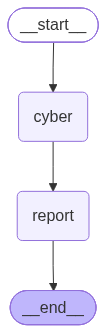

In [25]:
from IPython.display import Image, display
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)


## 16. Report — How the New Tools Improve the Assistant

*(Deliverable: short report. Edit this after reviewing your actual test-case outputs above.)*

Adding CISA KEV, MITRE ATT&CK, and EPSS turns the assistant from a "what vulnerabilities
exist" tool into a "what should I actually do first" tool:

- **CISA KEV** closes the gap between *disclosed* (NVD) and *actively exploited*
  vulnerabilities — it tells the analyst which findings represent real, confirmed
  in-the-wild risk rather than theoretical exposure, which is essential for prioritizing
  limited patching resources.
- **MITRE ATT&CK** adds the attacker's-eye view: instead of only listing vulnerable
  software, the assistant can now explain *how* an adversary would actually use a
  technique like Pass-the-Hash, which is directly useful for detection engineering and
  incident response, not just patch management.
- **EPSS** adds a quantitative, forward-looking risk signal (probability of exploitation
  in the next 30 days) that complements CVSS severity scores — letting the assistant
  recommend, for example, patching a medium-severity CVE with a high EPSS score before a
  critical-severity CVE with a near-zero EPSS score.
- **Consolidating into one Cyber Agent** (rather than a rigid keyword-routed
  planner) lets the LLM reason about compound queries naturally — e.g. Test Case 10 asks
  for CIS guidance + CVEs + KEV + ATT&CK + EPSS all at once, which the single
  tool-calling agent can satisfy by invoking several tools in one pass, whereas the v2.1
  keyword-based planner router could only ever activate the `rag` or `cve` branch (never
  both together generically, and never KEV/ATT&CK/EPSS at all).
- The **Report Agent** ensures every response is comparable across queries (same five
  sections every time), which matters for using this as a real workflow tool rather than
  a one-off chatbot answer.

**Limitations observed:** the MITRE ATT&CK tool downloads a large JSON file on every
call (no caching), which makes it noticeably slower than the other tools; a production
version should cache this locally and refresh it periodically instead of fetching on
every invocation. The CIS RAG tool (`ask_cis`) is still a placeholder pending the actual
Pinecone retriever wiring from Part 2, Section 4.


## 17. Exercises

Suggested enhancements and assignments.


### Suggested Assignments

- see activities\capstone.md


# Appendix

## Discussion Questions

- Why do we use tools instead of placing all logic inside one agent?
- What benefits does LangGraph provide over sequential execution?
- When should an agent call an external API instead of relying on RAG?
- How can hallucinations be reduced using validation loops?

## Best Practices

- Keep tools single-purpose.
- Keep prompts concise and explicit.
- Share only necessary state.
- Validate external data before presenting it.
- Log agent decisions for debugging and teaching.
